In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib 
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import font_manager, rc
path = "c:/Windows/Fonts/malgun.ttf"
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~')

In [6]:
data = pd.read_csv("C:/Users/PC/Desktop/산단공.csv", encoding = "cp949")
data.head()

,연번,시도명,관리기관,단지명,입주일,최초등록일,기준년월,노동지청,행정구역,대업종,...,요양승인일,사망승인일,근로손실일수,요양기간,근속기간,성별,연령,재해발생년도,재해발생월,재해발생일
0,164,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20180604.0,NaN,202012,서울관악,서울,기타의사업,...,20200708,NaN,147,91일 ~ 180일,1년 ~ 2년 미만,남,30세 ~ 34세,2019,12,19
1,719,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20100202.0,20210419.0,201812,서울관악,서울,기타의사업,...,20180906,NaN,221,6개월 ~ 1년미만,5년 ~ 10년 미만,남,50세 ~ 54세,2018,3,21
2,868,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,NaN,19970930.0,201912,서울관악,서울,제조업,...,20190404,NaN,113,91일 ~ 180일,4년 ~ 5년 미만,남,55세 ~ 59세,2019,1,12
3,892,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20060119.0,20060703.0,201912,서울관악,서울,제조업,...,20190122,NaN,42,29일 ~ 90일,10년 ~ 20년 미만,여,50세 ~ 54세,2018,12,12
4,898,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20140312.0,20140530.0,201812,서울관악,서울,제조업,...,20181026,NaN,149,91일 ~ 180일,1년 ~ 2년 미만,남,60세 ~ 64세,2018,10,7


In [7]:
data.shape

(19825, 33)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연번      19825 non-null  int64  
 1   시도명     19825 non-null  object 
 2   관리기관    19825 non-null  object 
 3   단지명     19825 non-null  object 
 4   입주일     19313 non-null  float64
 5   최초등록일   16449 non-null  float64
 6   기준년월    19825 non-null  int64  
 7   노동지청    19825 non-null  object 
 8   행정구역    19825 non-null  object 
 9   대업종     19825 non-null  object 
 10  중업종     19825 non-null  object 
 11  소업종     19825 non-null  object 
 12  근로자수    19825 non-null  int64  
 13  재해자구분   19825 non-null  object 
 14  발생형태    19825 non-null  object 
 15  직업병_대   19825 non-null  object 
 16  직업병_중   19825 non-null  object 
 17  직업병_소   19825 non-null  object 
 18  직업병_세   19825 non-null  object 
 19  직종_대    19825 non-null  object 
 20  직종_중    19825 non-null  object 
 21  직종_소    19825 non-null  object 
 22

In [9]:
data.isnull().sum()

연번            0
시도명           0
관리기관          0
단지명           0
입주일         512
최초등록일      3376
기준년월          0
노동지청          0
행정구역          0
대업종           0
중업종           0
소업종           0
근로자수          0
재해자구분         0
발생형태          0
직업병_대         0
직업병_중         0
직업병_소         0
직업병_세         0
직종_대          0
직종_중          0
직종_소          0
재해발생날짜        0
요양승인일         0
사망승인일     19514
근로손실일수        0
요양기간          0
근속기간          0
성별            0
연령            0
재해발생년도        0
재해발생월         0
재해발생일         0
dtype: int64

In [10]:
df = data.drop(columns = ["입주일", "최초등록일", "기준년월", "직업병_대", "직업병_중", "직업병_소", "직업병_세", "재해발생날짜", "요양승인일", "사망승인일", "근로손실일수", "요양기간", "근속기간", "성별", "연령"])
df.head()

,연번,시도명,관리기관,단지명,노동지청,행정구역,대업종,중업종,소업종,근로자수,재해자구분,발생형태,직종_대,직종_중,직종_소,재해발생년도,재해발생월,재해발생일
0,164,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,서울관악,서울,기타의사업,도소매·음식·숙박업,도소매및소비자용품수리업,7,사고부상자,체육행사 등의 사고,관리자,판매 및 고객서비스 관리직,판매 및 운송 관리자,2019,12,19
1,719,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,서울관악,서울,기타의사업,도소매·음식·숙박업,도소매및소비자용품수리업,7,사고부상자,체육행사 등의 사고,전문가 및 관련 종사자,경영·금융 전문가 및 관련직,기술영업 및 중개 관련종사자,2018,3,21
2,868,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,서울관악,서울,제조업,출판·인쇄·제본또는인쇄물가공업,인쇄업,4,사고부상자,넘어짐,장치ㆍ기계 조작 및 조립 종사자,전기 및 전자 관련 기계조작직,전기·전자 부품 및 제품 제조장치 조작원,2019,1,12
3,892,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,서울관악,서울,제조업,섬유및섬유제품제조업,의복및장신품등의제조업,2,사고부상자,넘어짐,기능원 및 관련 기능 종사자,섬유·의복 및 가죽 관련 기능직,섬유 및 가죽 관련 기능 종사자,2018,12,12
4,898,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,서울관악,서울,제조업,섬유및섬유제품제조업,직물업,4,사고부상자,끼임,장치ㆍ기계 조작 및 조립 종사자,섬유 및 신발 관련 기계조작직,섬유제조 및 가공기계조작원,2018,10,7


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      19825 non-null  int64 
 1   시도명     19825 non-null  object
 2   관리기관    19825 non-null  object
 3   단지명     19825 non-null  object
 4   노동지청    19825 non-null  object
 5   행정구역    19825 non-null  object
 6   대업종     19825 non-null  object
 7   중업종     19825 non-null  object
 8   소업종     19825 non-null  object
 9   근로자수    19825 non-null  int64 
 10  재해자구분   19825 non-null  object
 11  발생형태    19825 non-null  object
 12  직종_대    19825 non-null  object
 13  직종_중    19825 non-null  object
 14  직종_소    19825 non-null  object
 15  재해발생년도  19825 non-null  int64 
 16  재해발생월   19825 non-null  int64 
 17  재해발생일   19825 non-null  int64 
dtypes: int64(5), object(13)
memory usage: 2.7+ MB


In [12]:
!pip install dython

C:\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:214: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


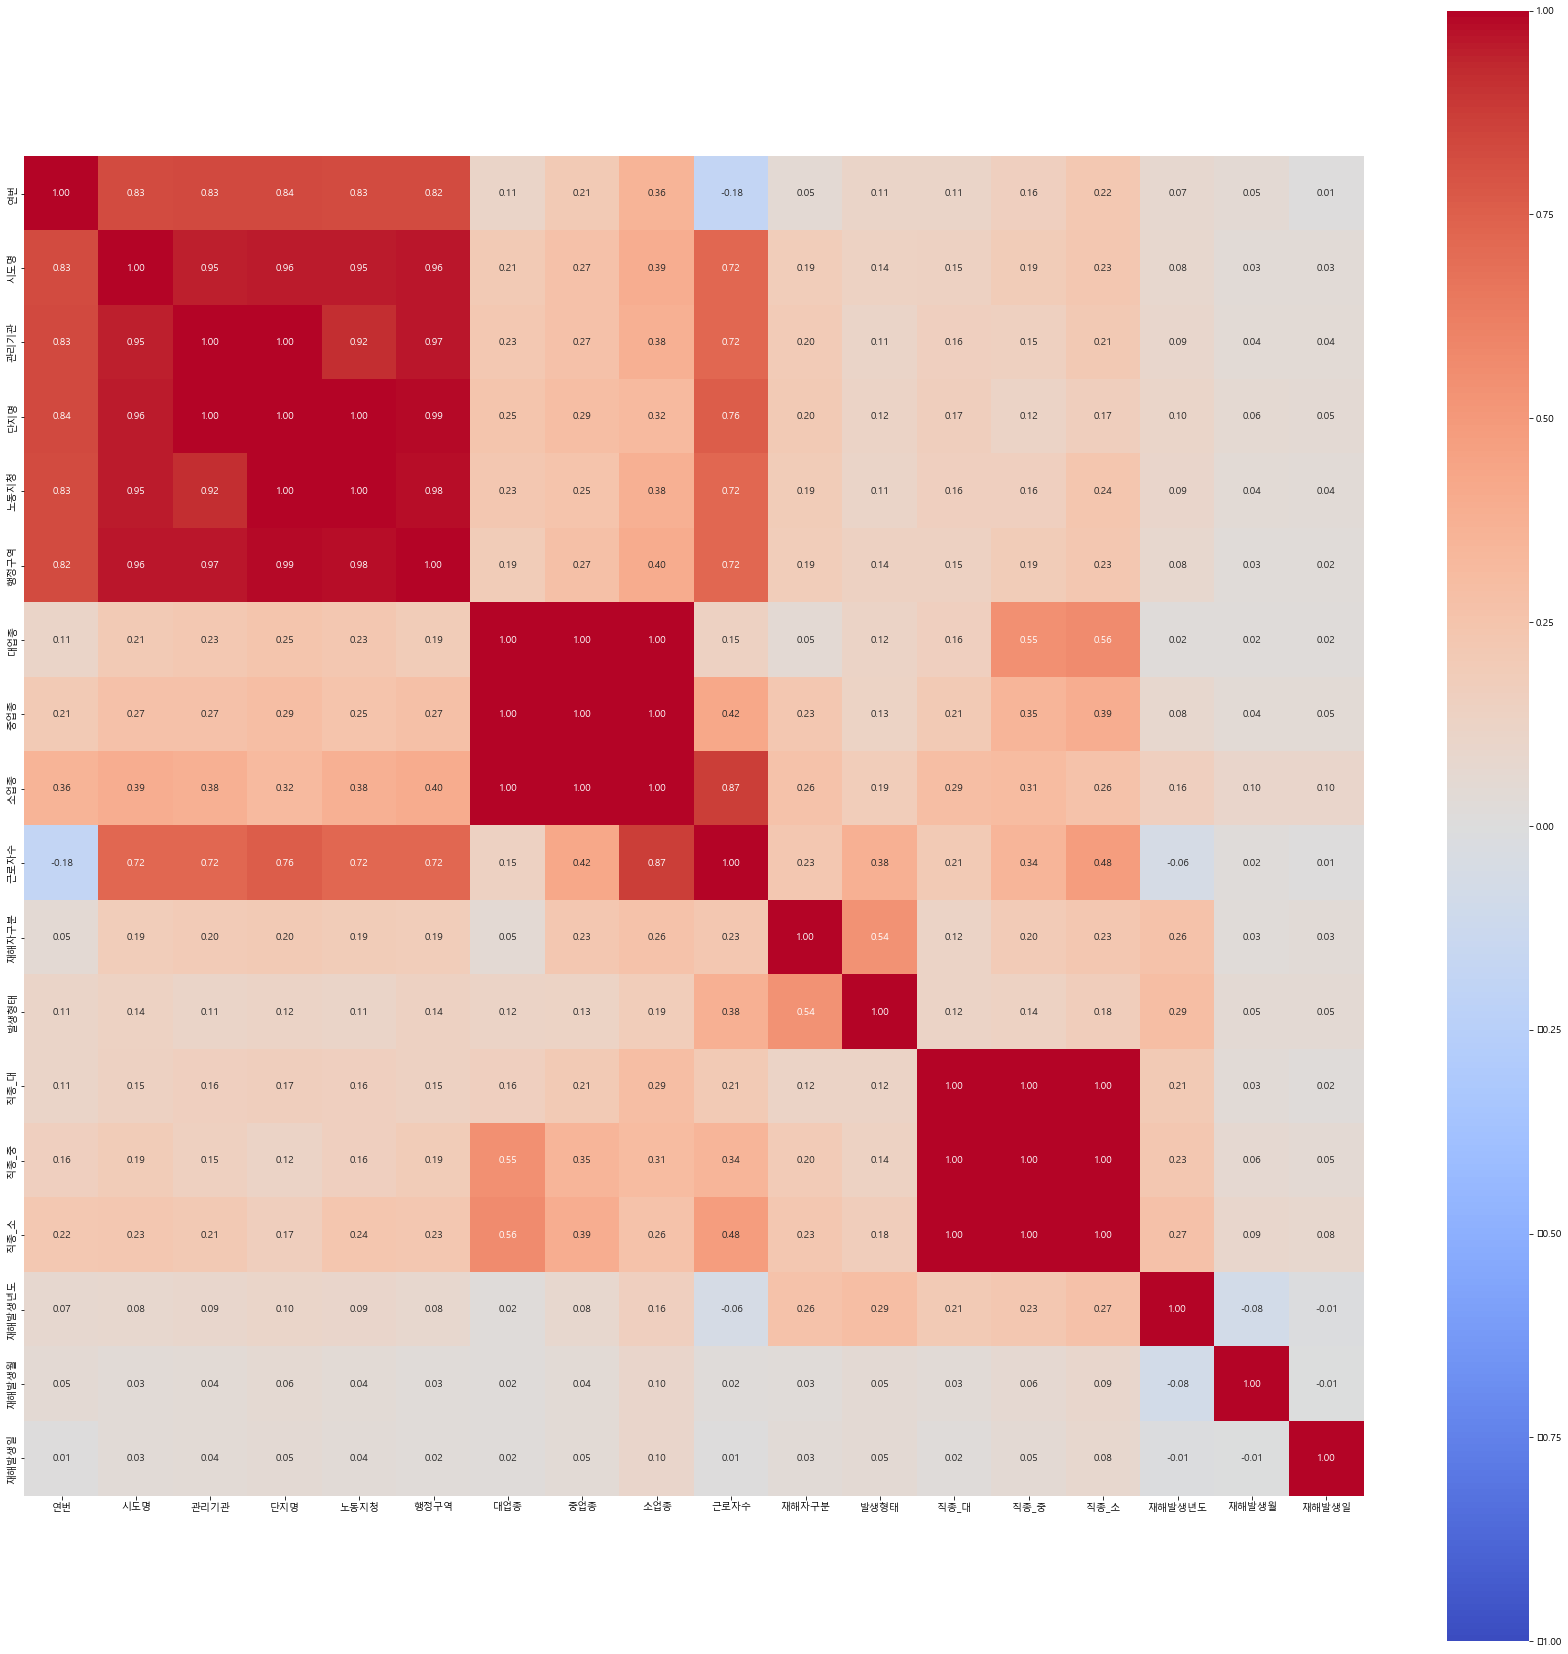

{'corr':               연번       시도명      관리기관       단지명      노동지청      행정구역       대업종  \
 연번      1.000000  0.826516  0.832903  0.835061  0.827074  0.821951  0.111650   
 시도명     0.826516  1.000000  0.948978  0.960329  0.954612  0.964373  0.209320   
 관리기관    0.832903  0.948978  1.000000  0.999219  0.919312  0.965772  0.225655   
 단지명     0.835061  0.960329  0.999219  1.000000  0.999242  0.991670  0.247976   
 노동지청    0.827074  0.954612  0.919312  0.999242  1.000000  0.981106  0.233755   
 행정구역    0.821951  0.964373  0.965772  0.991670  0.981106  1.000000  0.189244   
 대업종     0.111650  0.209320  0.225655  0.247976  0.233755  0.189244  1.000000   
 중업종     0.207796  0.270379  0.267196  0.289437  0.253367  0.274176  0.999546   
 소업종     0.358331  0.394947  0.379837  0.316392  0.376853  0.401217  0.995676   
 근로자수   -0.182007  0.720471  0.721170  0.758860  0.720886  0.720492  0.147234   
 재해자구분   0.052233  0.187269  0.195792  0.203795  0.194616  0.186958  0.049411   
 발생형태    0.111741  0

In [13]:
from dython.nominal import associations
associations(df, cmap = "coolwarm", figsize=(30, 30))

In [14]:
associations(df_대, cmap = "coolwarm", figsize=(30, 30))

NameError: name 'df_대' is not defined

In [ ]:
associations(df_중, cmap = "coolwarm", figsize=(30, 30))

In [ ]:
associations(df_소, cmap = "coolwarm", figsize=(30, 30))

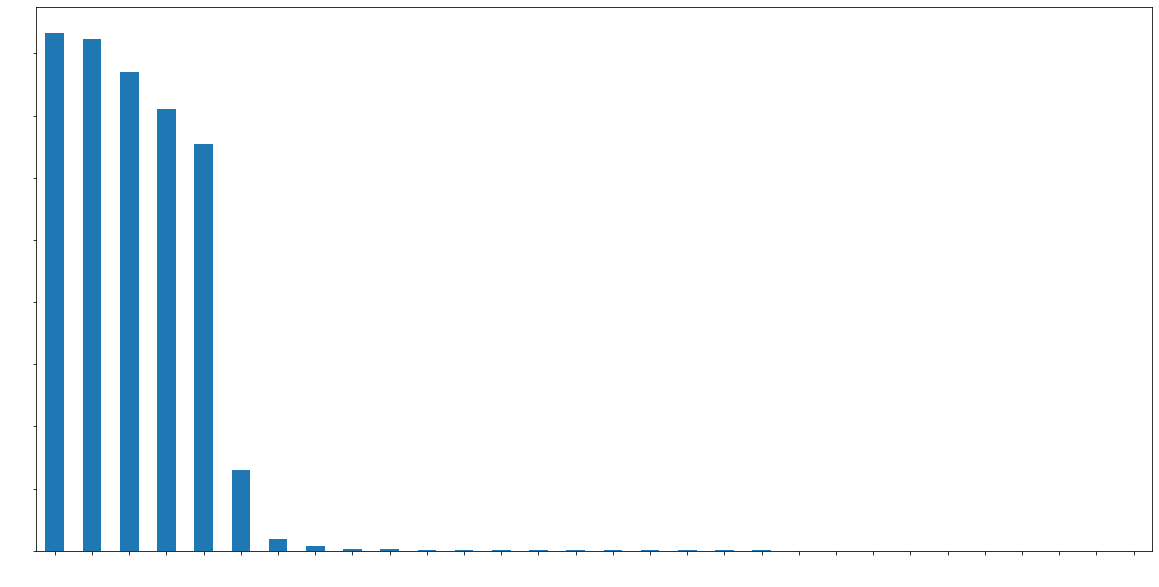

In [16]:
plt.figure(figsize = (20,10))
df.재해발생년도.value_counts().plot(kind = "bar")
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

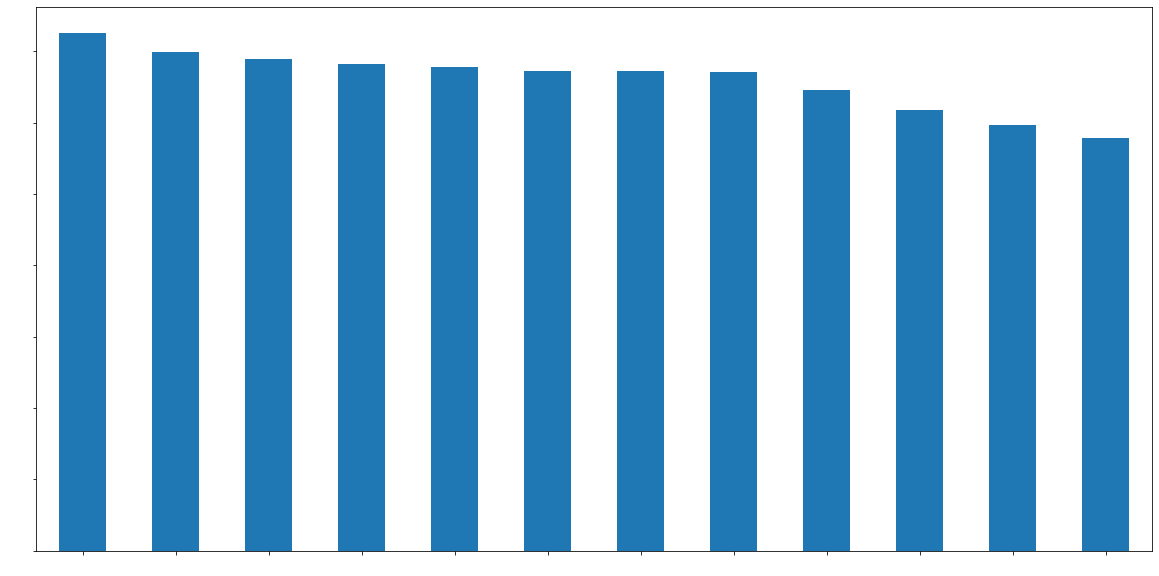

In [17]:
plt.figure(figsize = (20,10))
df.재해발생월.value_counts().plot(kind = "bar")
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

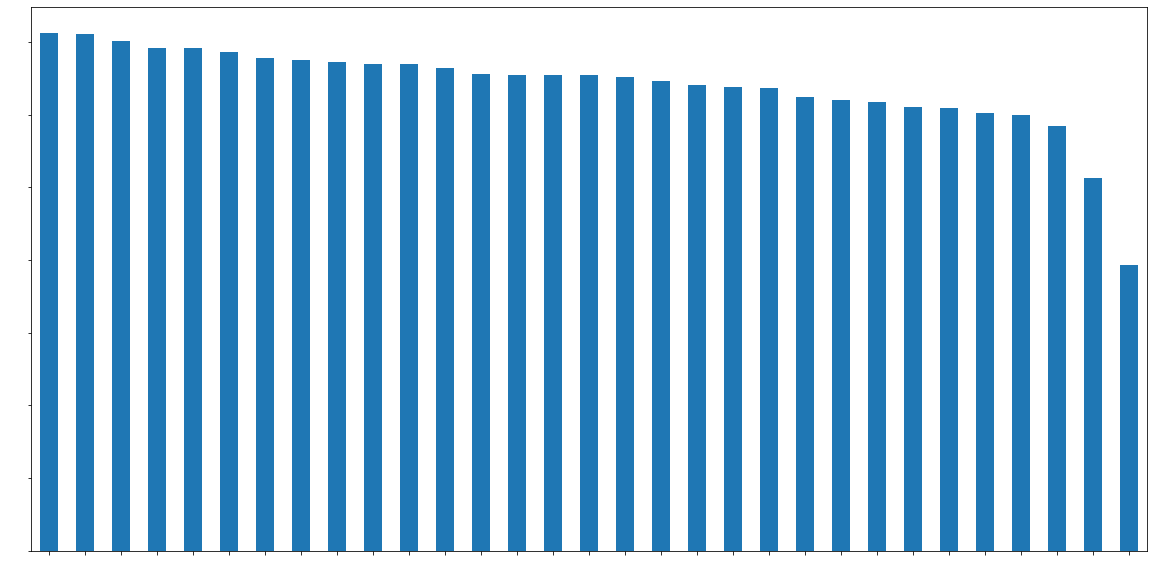

In [18]:
plt.figure(figsize = (20,10))
df.재해발생일.value_counts().plot(kind = "bar")
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

In [19]:
df_대 = df.drop(columns = ["연번", "시도명", "노동지청", "행정구역", "관리기관", "중업종", "소업종", "직종_중", "직종_소"])
df_중 = df.drop(columns = ["연번", "시도명", "노동지청", "행정구역", "관리기관", "대업종", "소업종", "직종_대", "직종_소"])
df_소 = df.drop(columns = ["연번", "시도명", "노동지청", "행정구역", "관리기관", "대업종", "중업종", "직종_대", "직종_중"])

In [20]:
df.columns

Index(['연번', '시도명', '관리기관', '단지명', '노동지청', '행정구역', '대업종', '중업종', '소업종', '근로자수',
       '재해자구분', '발생형태', '직종_대', '직종_중', '직종_소', '재해발생년도', '재해발생월', '재해발생일'],
      dtype='object')

In [21]:
en_list = df.dtypes[(df.dtypes=='object')].index
for i in en_list:
  encoder = LabelEncoder()
  encoder.fit(df[i])
  df[i] = encoder.transform(df[i])
df.head()

,연번,시도명,관리기관,단지명,노동지청,행정구역,대업종,중업종,소업종,근로자수,재해자구분,발생형태,직종_대,직종_중,직종_소,재해발생년도,재해발생월,재해발생일
0,164,7,15,25,10,7,2,7,54,7,1,21,1,50,122,2019,12,19
1,719,7,15,25,10,7,2,7,54,7,1,21,9,8,32,2018,3,21
2,868,7,15,25,10,7,6,21,114,4,1,4,8,43,105,2019,1,12
3,892,7,15,25,10,7,6,11,111,2,1,4,2,32,69,2018,12,12
4,898,7,15,25,10,7,6,11,141,4,1,3,8,31,70,2018,10,7


In [22]:
en_list = df_대.dtypes[(df_대.dtypes=='object')].index
for i in en_list:
  encoder = LabelEncoder()
  encoder.fit(df_대[i])
  df_대[i] = encoder.transform(df_대[i])

In [23]:
en_list = df_중.dtypes[(df_중.dtypes=='object')].index
for i in en_list:
  encoder = LabelEncoder()
  encoder.fit(df_중[i])
  df_중[i] = encoder.transform(df_중[i])

In [24]:
en_list = df_소.dtypes[(df_소.dtypes=='object')].index
for i in en_list:
  encoder = LabelEncoder()
  encoder.fit(df_소[i])
  df_소[i] = encoder.transform(df_소[i])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   연번      19825 non-null  int64
 1   시도명     19825 non-null  int32
 2   관리기관    19825 non-null  int32
 3   단지명     19825 non-null  int32
 4   노동지청    19825 non-null  int32
 5   행정구역    19825 non-null  int32
 6   대업종     19825 non-null  int32
 7   중업종     19825 non-null  int32
 8   소업종     19825 non-null  int32
 9   근로자수    19825 non-null  int64
 10  재해자구분   19825 non-null  int32
 11  발생형태    19825 non-null  int32
 12  직종_대    19825 non-null  int32
 13  직종_중    19825 non-null  int32
 14  직종_소    19825 non-null  int32
 15  재해발생년도  19825 non-null  int64
 16  재해발생월   19825 non-null  int64
 17  재해발생일   19825 non-null  int64
dtypes: int32(13), int64(5)
memory usage: 1.7 MB


In [26]:
x_대 = df_대.drop(columns= ["발생형태"])
y_대 = df_대.발생형태

In [27]:
x_중 = df_중.drop(columns= ["발생형태"])
y_중 = df_중.발생형태

In [28]:
x_소 = df_소.drop(columns= ["발생형태"])
y_소 = df_소.발생형태

In [29]:
x = df.drop(columns = "발생형태")
y = df.발생형태